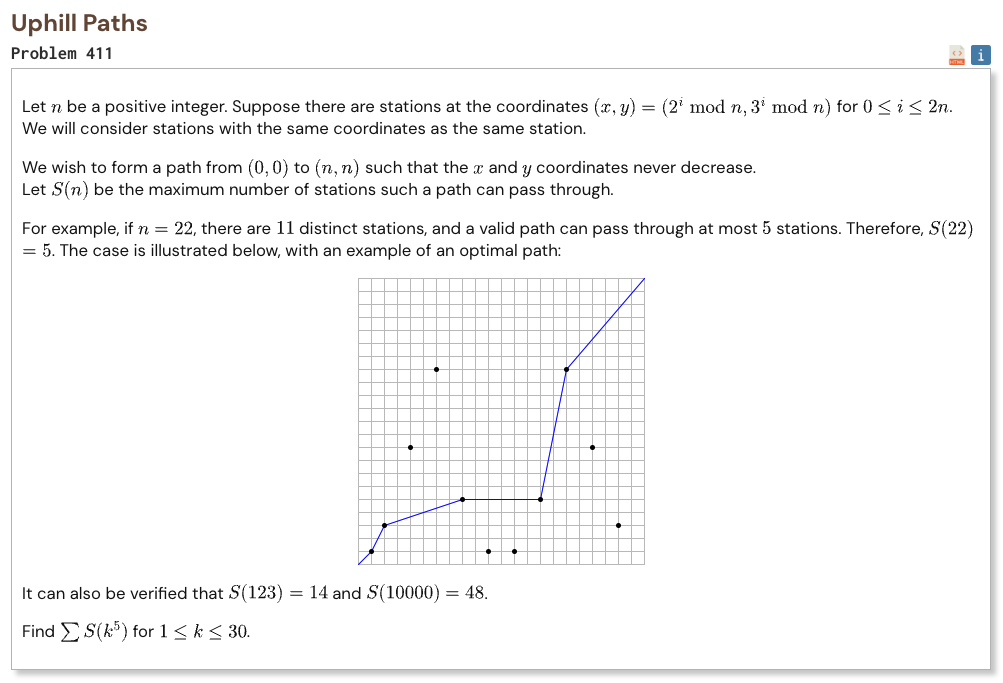

## Initial approach

-   generate the stations by repeatedly updating both coordinates with modular arithmetic
-   stop when the repeating part returns to its starting position
-   pack each coordinate pair into one integer to save memory
-   sort the packed values and ignore duplicate stations
-   find the longest nondecreasing sequence of heights after sorting by horizontal position
-   use bisect right because stations at the same height can appear on one valid path
-   use numpy to store and sort the millions of stations efficiently

In [1]:
from bisect import bisect_right
import numpy as np

def valuation(value, prime):
    count = 0
    while value % prime == 0:
        value //= prime
        count += 1
    return count

def station_count(n):
    tail = max(valuation(n, 2), valuation(n, 3))
    bits = n.bit_length()
    mask = (1 << bits) - 1

    stations = np.empty(n + tail + 1, dtype=np.uint64)

    x = 1 % n
    y = 1 % n
    count = 0

    for _ in range(tail):
        stations[count] = (x << bits) | y
        count += 1
        x = 2 * x % n
        y = 3 * y % n

    start_x = x
    start_y = y

    while True:
        stations[count] = (x << bits) | y
        count += 1
        x = 2 * x % n
        y = 3 * y % n

        if x == start_x and y == start_y:
            break

    stations = stations[:count]
    stations.sort()

    tails = []
    previous = -1

    for packed in stations:
        value = int(packed)

        if value == previous:
            continue

        previous = value
        y = value & mask
        position = bisect_right(tails, y)

        if position == len(tails):
            tails.append(y)
        else:
            tails[position] = y

    return len(tails)

In [2]:
%%time

result = sum(station_count(k ** 5) for k in range(1, 31))
print("Result:", result)

Result: 9936352
CPU times: user 19.9 s, sys: 246 ms, total: 20.1 s
Wall time: 20.5 s
